# **Problem Statement:** 

The Indian Premier League (IPL) is one of the world's most popular T20 cricket tournaments, generating large volumes of match and player performance data every season. This project aims to analyze historical IPL match and ball-by-ball datasets using Python and the Pandas library to uncover meaningful insights into team performance, player statistics, match outcomes, and tournament trends.

By performing data cleaning, exploratory data analysis (EDA), and visualization, the project seeks to answer key questions such as:

Which teams have been the most successful across IPL seasons?
Does winning the toss significantly influence match results?
Which players have consistently delivered outstanding performances?
Which venues favor batting first or chasing?
What scoring and wicket-taking trends can be observed over different seasons?

The findings from this analysis can help cricket enthusiasts, analysts, and decision-makers better understand team strategies, player contributions, and historical patterns within the IPL.

# **Objective:**

1. Clean and preprocess IPL datasets for analysis.
2. Explore team, player, and venue performance using Pandas.
3. Visualize important trends through informative charts and graphs.
4. Generate data-driven insights from historical IPL data.
5. Strengthen practical skills in Python, Pandas, Matplotlib, and Seaborn for exploratory data analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches=pd.read_csv("data/matches.csv")
deliveries=pd.read_csv("data/deliveries.csv")

In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


# **Exploratory Data Analysis**

# 1. Data Inspection:

How big is the dataset?

In [5]:
matches.shape

(1095, 20)

Interpretation :

The matches dataset contains 1095 rows and 20 columns.
Each row represents a match of the IPL


In [6]:
deliveries.shape

(260920, 17)

Interpretation : 
The deliveries dataset contains 260920 rows and 17 columns.
Each row represents a ball(delivery) in a match

Observation
1. The matches dataset provides match-level information.
2. The deliveries dataset provides ball-by-ball information.

Features Available for Analysis

What columns are available?

In [7]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

| Column            | Description                                        |
| ----------------- | -------------------------------------------------- |
| `id`              | Unique match identifier                            |
| `season`          | IPL season in which the match was played           |
| `city`            | City where the match took place                    |
| `date`            | Date of the match                                  |
| `match_type`      | Type of match (League, Eliminator, Final, etc.)    |
| `player_of_match` | Player awarded "Player of the Match"               |
| `venue`           | Stadium where the match was played                 |
| `team1`           | First competing team                               |
| `team2`           | Second competing team                              |
| `toss_winner`     | Team that won the toss                             |
| `toss_decision`   | Decision after winning the toss (Bat/Field)        |
| `winner`          | Team that won the match                            |
| `result`          | Match result (Runs/Wickets/Tie/No Result)          |
| `result_margin`   | Margin of victory                                  |
| `target_runs`     | Target score for the chasing team                  |
| `target_overs`    | Overs available while chasing                      |
| `super_over`      | Whether the match went to a Super Over             |
| `method`          | Method used if the match was shortened (e.g., DLS) |
| `umpire1`         | First on-field umpire                              |
| `umpire2`         | Second on-field umpire                             |


In [8]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

| Column             | Description                                       |
| ------------------ | ------------------------------------------------- |
| `match_id`         | Match identifier (links to `matches.id`)          |
| `inning`           | Innings number                                    |
| `batting_team`     | Batting team                                      |
| `bowling_team`     | Bowling team                                      |
| `over`             | Over number                                       |
| `ball`             | Ball number within the over                       |
| `batter`           | Batter facing the delivery                        |
| `bowler`           | Bowler delivering the ball                        |
| `non_striker`      | Batter at the non-striker's end                   |
| `batsman_runs`     | Runs scored by the batter                         |
| `extra_runs`       | Extra runs awarded                                |
| `total_runs`       | Total runs scored on the delivery                 |
| `extras_type`      | Type of extra (Wide, No-ball, Bye, Leg Bye)       |
| `is_wicket`        | Indicates whether a wicket fell (1 = Yes, 0 = No) |
| `player_dismissed` | Name of the dismissed player                      |
| `dismissal_kind`   | Type of dismissal (Caught, Bowled, Run Out, etc.) |
| `fielder`          | Fielder involved in the dismissal (if applicable) |


The matches dataset contains match-level information such as teams, venue, toss details, match winner, and player of the match. The deliveries dataset contains ball-by-ball information, including batting and bowling details, runs scored, and wicket events. Both datasets are connected using the id and match_id columns, enabling comprehensive match analysis.

What are the data types?

In [9]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [10]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

#Interpret

The matches dataset consists of 1,095 records and 20 columns. Most columns are categorical (object), while a few are numerical. Some columns contain missing values, particularly method, which is only applicable to matches affected by special playing conditions.

The deliveries dataset contains 260,920 ball-by-ball records with 17 columns. Missing values in columns such as extras_type, player_dismissed, dismissal_kind, and fielder are expected because they only apply to specific events during a match and therefore do not require imputation.

In [11]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


# Interpretation of matches.describe() :
# Observations
The dataset contains 1095 matches, as indicated by the count for the id column.
The average winning margin (result_margin) is approximately 17.26, although the actual margin varies significantly across matches.
The average target score (target_runs) is around 166 runs, which is typical for T20 cricket.
The target overs value is 20 for most matches, indicating that nearly all matches were played as full 20-over games. A few matches have fewer overs due to weather or special match conditions.

In [12]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


# Interpretation of deliveries.describe()
# Observations
The dataset contains 260,920 deliveries, representing every recorded ball in the IPL dataset.
The average runs scored per ball (total_runs) is approximately 1.33, reflecting both batting runs and extras.
The average batsman_runs per delivery is about 1.27, showing that singles are the most common scoring outcome.
The is_wicket column has a mean of approximately 0.05, indicating that wickets occur on roughly 5% of deliveries, which aligns with the nature of T20 cricket.

# Key Takeaway:

The IPL datasets are well-structured, with most numerical columns showing realistic values. Missing values are limited and primarily occur in columns where they are expected due to match-specific events, indicating good overall data quality.

Are there missing values?

In [13]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [14]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

Are there duplicate records?

In [15]:
matches.duplicated().sum()

0

In [16]:
deliveries.duplicated().sum()

0

# Data Cleaning

In [17]:
matches.isnull().sum().sort_values(ascending=False)

method             1074
city                 51
result_margin        19
winner                5
player_of_match       5
target_overs          3
target_runs           3
id                    0
umpire1               0
super_over            0
result                0
toss_decision         0
season                0
toss_winner           0
team2                 0
team1                 0
venue                 0
match_type            0
date                  0
umpire2               0
dtype: int64

The matches dataset contains a small number of missing values. After examining each column, it was found that these missing values represent valid match scenarios such as rain-affected games, tied matches, or no-result matches rather than data quality issues. Therefore, no missing value imputation or row removal was performed, ensuring that the original match information is preserved.

In [18]:
matches['date']=pd.to_datetime(matches['date'])

In [19]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   object        
 2   city             1044 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-null   float64

In [20]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri


In [21]:
matches['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [22]:
matches['team2'].unique()
matches['winner'].unique()
matches['toss_winner'].unique()

array(['Royal Challengers Bangalore', 'Chennai Super Kings',
       'Rajasthan Royals', 'Mumbai Indians', 'Deccan Chargers',
       'Kings XI Punjab', 'Kolkata Knight Riders', 'Delhi Daredevils',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

In [23]:
team_columns = ['team1', 'team2', 'toss_winner', 'winner']

teams = pd.concat([matches[col] for col in team_columns]).dropna().unique()


In [24]:
teams

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [25]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [26]:
deliveries.isnull().sum().sort_values(ascending=False)

fielder             251566
dismissal_kind      247970
player_dismissed    247970
extras_type         246795
batsman_runs             0
is_wicket                0
total_runs               0
extra_runs               0
match_id                 0
inning                   0
bowler                   0
batter                   0
ball                     0
over                     0
bowling_team             0
batting_team             0
non_striker              0
dtype: int64

In [27]:
teams_del_col=["batting_team","bowling_team"]
teams1=pd.concat([deliveries[col] for col in teams_del_col]).dropna().unique()

In [28]:
teams1

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Kings XI Punjab', 'Rajasthan Royals',
       'Delhi Daredevils', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [29]:
set(teams)==set(teams1)

True

In [30]:
# Dictionary containing old and new team names
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

# Replace team names in the matches dataset
matches.replace(team_name_mapping, inplace=True)

# Replace team names in the deliveries dataset
deliveries.replace(team_name_mapping, inplace=True)

In [31]:
team_columns = ['team1', 'team2', 'toss_winner', 'winner']

teams = pd.concat([matches[col] for col in team_columns]).dropna().unique()
teams

array(['Royal Challengers Bengaluru', 'Punjab Kings', 'Delhi Capitals',
       'Mumbai Indians', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Deccan Chargers', 'Chennai Super Kings', 'Kochi Tuskers Kerala',
       'Pune Warriors', 'Sunrisers Hyderabad', 'Gujarat Lions',
       'Rising Pune Supergiants', 'Lucknow Super Giants',
       'Gujarat Titans'], dtype=object)

In [32]:
teams_del_col=["batting_team","bowling_team"]
teams1=pd.concat([deliveries[col] for col in teams_del_col]).dropna().unique()
teams1

array(['Kolkata Knight Riders', 'Royal Challengers Bengaluru',
       'Chennai Super Kings', 'Punjab Kings', 'Rajasthan Royals',
       'Delhi Capitals', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions', 'Lucknow Super Giants',
       'Gujarat Titans'], dtype=object)

In [33]:
set(teams)==set(teams1)

True

# Interpretation

Team names were standardized to account for franchise rebranding and naming inconsistencies across IPL seasons. This ensures that the same franchise is represented consistently throughout the analysis, preventing duplicate records for teams with different historical names. The standardization was applied to both the matches and deliveries datasets to maintain consistency.

# Completed

# Data Understanding

Imported libraries

Loaded datasets

Checked shape

Inspected columns

Used info()

Used describe()

# Data Cleaning

Checked missing values

Checked duplicates

Converted date to datetime

Standardized team names

# **Exploratory Data Analysis (EDA)**

# Business Question 1

1. Which IPL team has won the highest number of matches?

# Objective

The objective of this analysis is to identify the most successful IPL teams based on the total number of matches won. Understanding team performance helps evaluate consistency, competitiveness, and long-term success across IPL seasons.

In [34]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri


In [35]:
teams_winner=matches['winner'].value_counts()
teams_winner

Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: winner, dtype: int64

# Output Interpretation

The output displays each IPL team along with the total number of matches it has won.

The teams are automatically sorted in descending order, meaning the team with the highest number of victories appears at the top.

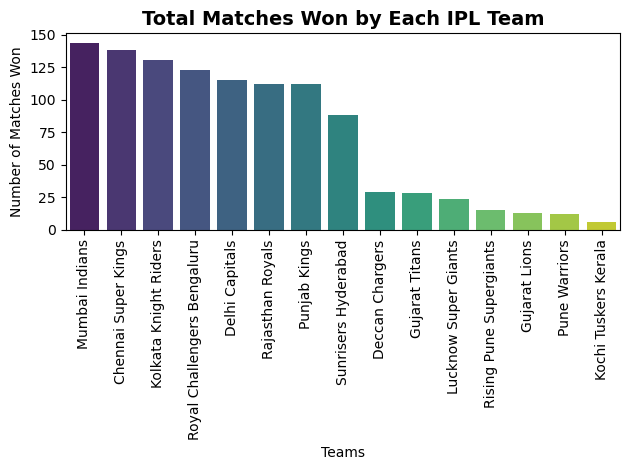

In [36]:
sns.barplot(x=teams_winner.index,y=teams_winner.values,palette='viridis')
plt.title("Total Matches Won by Each IPL Team",fontsize=14,fontweight='bold')
plt.xlabel("Teams")
plt.ylabel("Number of Matches Won")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

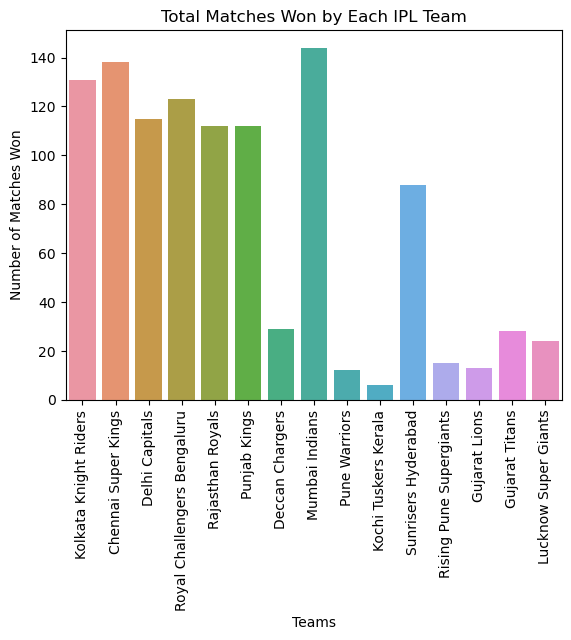

In [37]:
sns.countplot(x='winner',data=matches)
plt.title("Total Matches Won by Each IPL Team")
plt.xlabel("Teams")
plt.ylabel("Number of Matches Won")

plt.xticks(rotation=90)

plt.show()


# Interpretation

The visualization shows the total number of matches won by each IPL franchise across all recorded seasons. Mumbai Indians have won the highest number of matches, followed closely by Chennai Super Kings and Kolkata Knight Riders. On the other hand, teams such as Kochi Tuskers Kerala, Pune Warriors, and Gujarat Lions have significantly fewer victories, largely because they participated in fewer IPL seasons.

# Business Insight

The analysis indicates that franchises such as Mumbai Indians, Chennai Super Kings, and Kolkata Knight Riders have consistently performed well over multiple IPL seasons. Their sustained success may be attributed to stable leadership, effective player recruitment, strategic decision-making, and long-term team development. In contrast, teams with fewer victories generally had shorter participation periods or inconsistent performances.

2. Which IPL team has the highest win percentage?

In [38]:
team1_value=matches['team1'].value_counts()
team1_value

Royal Challengers Bengaluru    144
Chennai Super Kings            128
Delhi Capitals                 126
Punjab Kings                   123
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Sunrisers Hyderabad             86
Deccan Chargers                 39
Pune Warriors                   23
Lucknow Super Giants            23
Gujarat Titans                  21
Gujarat Lions                   16
Rising Pune Supergiants         14
Kochi Tuskers Kerala             7
Name: team1, dtype: int64

In [39]:
team2_value=matches['team2'].value_counts()
team2_value

Mumbai Indians                 138
Kolkata Knight Riders          130
Delhi Capitals                 126
Punjab Kings                   123
Rajasthan Royals               120
Royal Challengers Bengaluru    111
Chennai Super Kings            110
Sunrisers Hyderabad             96
Deccan Chargers                 36
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Rising Pune Supergiants         16
Gujarat Lions                   14
Kochi Tuskers Kerala             7
Name: team2, dtype: int64

In [40]:
total_played=team1_value.add(team2_value,fill_value=0)
total_played

Chennai Super Kings            238
Deccan Chargers                 75
Delhi Capitals                 252
Gujarat Lions                   30
Gujarat Titans                  45
Kochi Tuskers Kerala            14
Kolkata Knight Riders          251
Lucknow Super Giants            44
Mumbai Indians                 261
Pune Warriors                   46
Punjab Kings                   246
Rajasthan Royals               221
Rising Pune Supergiants         30
Royal Challengers Bengaluru    255
Sunrisers Hyderabad            182
dtype: int64

In [41]:
match_win=matches['winner'].value_counts()
match_win

Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: winner, dtype: int64

In [42]:
Percentage_win=((match_win/total_played)*100).sort_values(ascending=False)
Percentage_win

Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Rising Pune Supergiants        50.000000
Sunrisers Hyderabad            48.351648
Royal Challengers Bengaluru    48.235294
Delhi Capitals                 45.634921
Punjab Kings                   45.528455
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Deccan Chargers                38.666667
Pune Warriors                  26.086957
dtype: float64

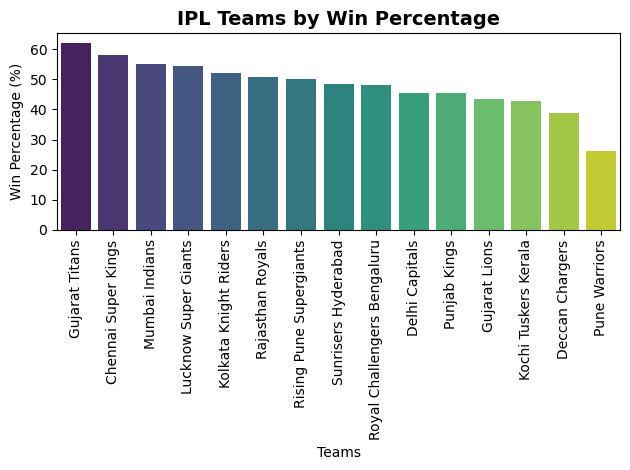

In [43]:
sns.barplot(x=Percentage_win.index,y=Percentage_win.values,palette='viridis')
plt.title("IPL Teams by Win Percentage", fontsize=14, fontweight='bold')
plt.xlabel("Teams")
plt.ylabel("Win Percentage (%)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Interpretation

The visualization shows the win percentage of each IPL franchise. Unlike total match wins, this metric considers the number of matches played, making it a fair comparison across teams.

Gujarat Titans have the highest win percentage, indicating exceptional performance since joining the IPL.
Chennai Super Kings and Mumbai Indians continue to rank among the top-performing teams, reflecting both consistency and long-term success.
Teams such as Pune Warriors and Deccan Chargers have relatively lower win percentages, indicating comparatively weaker overall performance.

# Business Insight

Win percentage is a more reliable measure of team performance than total match wins because it accounts for the number of matches played. While newer franchises like Gujarat Titans have played fewer seasons, they have converted a higher proportion of their matches into victories. Established teams such as Mumbai Indians and Chennai Super Kings demonstrate sustained excellence by maintaining high win percentages over a much larger number of matches.

# Business Question 
**3. Does winning the toss increase the chances of winning the match?**

# Objective

The objective of this analysis is to determine whether winning the toss provides a competitive advantage by increasing a team's chances of winning the match.

In [44]:
matches.head(1)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen


In [45]:
matches['toss_match_win']=matches['toss_winner']==matches['winner']
matches[['toss_winner','winner','toss_match_win']].head()

,toss_winner,winner,toss_match_win
0,Royal Challengers Bengaluru,Kolkata Knight Riders,False
1,Chennai Super Kings,Chennai Super Kings,True
2,Rajasthan Royals,Delhi Capitals,False
3,Mumbai Indians,Royal Challengers Bengaluru,False
4,Deccan Chargers,Kolkata Knight Riders,False


In [46]:
toss_match_results=matches['toss_match_win'].value_counts()
toss_match_results

True     554
False    541
Name: toss_match_win, dtype: int64

In [47]:
toss_match_percentage = (
    matches['toss_match_win']
    .value_counts(normalize=True) *100
).round(2)

toss_match_percentage

True     50.59
False    49.41
Name: toss_match_win, dtype: float64

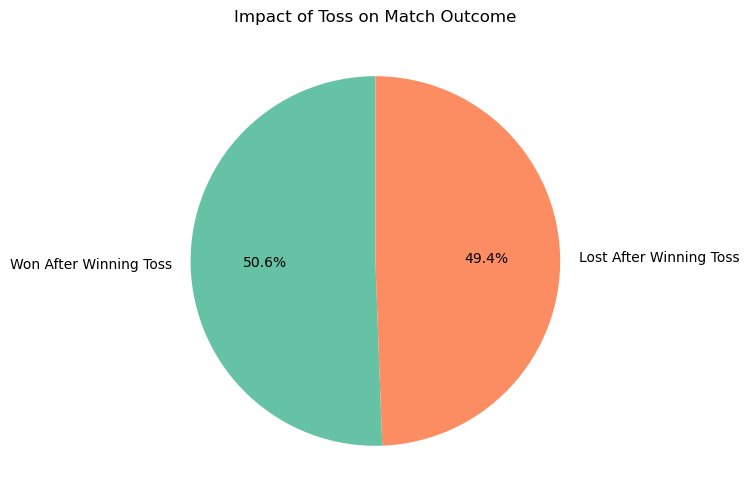

In [48]:
plt.figure(figsize=(6,6))

plt.pie(
    toss_match_results,
    labels=['Won After Winning Toss', 'Lost After Winning Toss'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62']
)

plt.title("Impact of Toss on Match Outcome")

plt.show()

# Interpretation

The pie chart shows that:

50.6% of the matches were won by the team that won the toss.
49.4% of the matches were won by the team that lost the toss.

The difference between the two outcomes is only 1.2%.

This indicates that the toss has very little influence on the final result.

# Business Insight

Although winning the toss provides teams with the opportunity to choose whether to bat or field first, the analysis reveals that it does not significantly impact the match outcome. Teams that lose the toss still win nearly half of the matches, suggesting that overall team performance, player execution, and match strategy are far more influential than the toss itself.

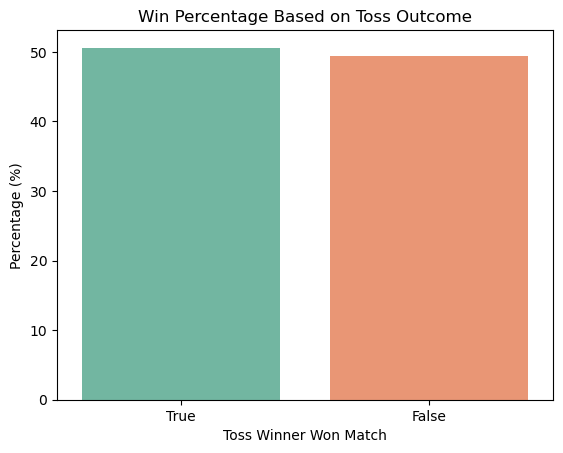

In [49]:
sns.barplot(
x=toss_match_percentage.index.astype(str),y=toss_match_percentage.values,palette='Set2'
)
plt.title("Win Percentage Based on Toss Outcome")
plt.xlabel("Toss Winner Won Match")
plt.ylabel("Percentage (%)")

plt.show()

**4. Which players have won the most Player of the Match awards?**

# Objective

To identify the players who have received the highest number of Player of the Match awards.

In [50]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True


In [51]:
player_awards=matches['player_of_match'].value_counts()
player_awards

AB de Villiers       25
CH Gayle             22
RG Sharma            19
DA Warner            18
V Kohli              18
                     ..
NV Ojha               1
KV Sharma             1
Washington Sundar     1
PD Collingwood        1
Shahbaz Ahmed         1
Name: player_of_match, Length: 291, dtype: int64

In [52]:
tup_10players=player_awards.head(10)
tup_10players

AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: player_of_match, dtype: int64

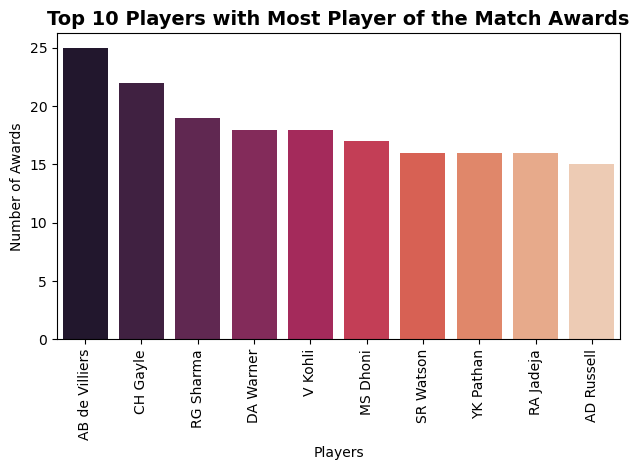

In [53]:
sns.barplot(x=tup_10players.index,y=tup_10players.values,palette='rocket')
plt.title("Top 10 Players with Most Player of the Match Awards",
          fontsize=14,
          fontweight='bold')
plt.xlabel("Players")
plt.ylabel("Number of Awards")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Interpretation

The bar chart shows the Top 10 players with the highest number of Player of the Match awards in IPL history.

AB de Villiers leads the list with 25 awards, making him the most impactful player in the dataset.
Chris Gayle follows with 22 awards, reflecting his dominance as an explosive opening batter.
Rohit Sharma, David Warner, and Virat Kohli are also among the top performers, demonstrating consistent match-winning contributions over multiple IPL seasons.
The relatively small difference between players ranked 3rd to 10th suggests strong competition among the league's elite performers.

# Business Insight

The analysis highlights the importance of consistent individual performances in influencing match outcomes. Players such as AB de Villiers, Chris Gayle, and Virat Kohli have repeatedly delivered under pressure, making them valuable assets for their franchises. Identifying such high-impact players can help teams make informed decisions regarding player retention, leadership roles, and auction strategies.

# Conclusion:
Player of the Match awards highlight players who consistently delivered match-winning performances rather than simply accumulating statistics. These awards recognize players who made decisive contributions under varying match conditions.

**5. Which stadiums have hosted the highest number of IPL matches?**

In [54]:
venue_matches = matches['venue'].value_counts()

venue_matches

Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    65
Feroz Shah Kotla                                                         60
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Wankhede Stadium, Mumbai                                                 45
Punjab Cricket Association Stadium, Mohali                               35
Sheikh Zayed Stadium                                                     29
Sharjah Cricket Stadium                                                  28
MA Chidambaram Stadium, Chepauk, Chennai                                 28
Narendra Mod

In [55]:
top10_venues = venue_matches.head(10)

top10_venues

Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: venue, dtype: int64

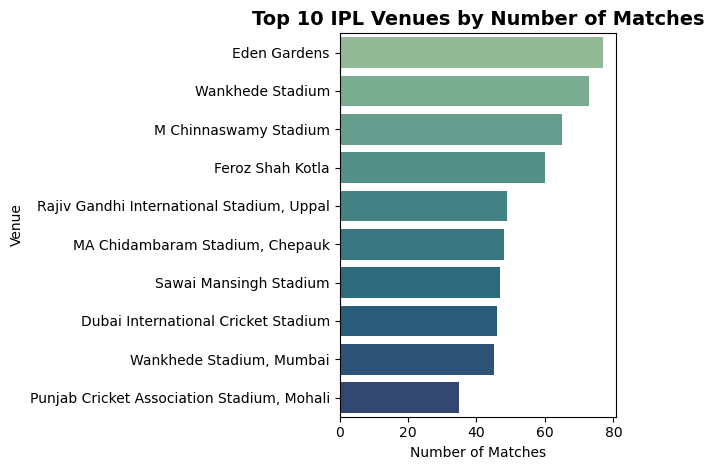

In [56]:

sns.barplot(
    x=top10_venues.values,
    y=top10_venues.index,
    palette='crest'
)

plt.title("Top 10 IPL Venues by Number of Matches", fontsize=14, fontweight='bold')
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()

plt.show()

# Interpretation

The visualization shows the Top 10 venues that have hosted the highest number of IPL matches.

Eden Gardens has hosted the highest number of IPL matches, making it one of the most frequently used venues in the tournament.
Wankhede Stadium and M. Chinnaswamy Stadium also rank among the top venues, reflecting their long-standing association with IPL franchises and their importance in hosting high-profile matches.
Venues such as MA Chidambaram Stadium, Sawai Mansingh Stadium, and Rajiv Gandhi International Stadium have consistently hosted matches over multiple IPL seasons, highlighting their significance in the tournament.

# Business Insight

The analysis indicates that a small number of iconic stadiums account for a significant proportion of IPL matches. These venues are preferred because of their established infrastructure, home-team presence, spectator capacity, and experience in hosting large-scale cricket events. Such insights can assist tournament organizers in scheduling matches, planning logistics, and improving fan engagement at key venues.

# Limitation: 
Some venue names may contain minor naming variations, which could slightly affect the venue-wise analysis

# Business Question 6

6. Which cities have hosted the highest number of IPL matches?

# Objective

To identify the cities that have hosted the highest number of IPL matches and analyze the geographical distribution of IPL venues.

In [57]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True


In [58]:
city_matches = matches['city'].value_counts()

city_matches

Mumbai            173
Kolkata            93
Delhi              90
Chennai            85
Hyderabad          77
Bangalore          65
Chandigarh         61
Jaipur             57
Pune               51
Abu Dhabi          37
Ahmedabad          36
Bengaluru          29
Durban             15
Visakhapatnam      15
Lucknow            14
Dubai              13
Dharamsala         13
Centurion          12
Rajkot             10
Sharjah            10
Indore              9
Navi Mumbai         9
Johannesburg        8
Cuttack             7
Port Elizabeth      7
Ranchi              7
Cape Town           7
Raipur              6
Mohali              5
Kochi               5
Kanpur              4
Kimberley           3
East London         3
Guwahati            3
Nagpur              3
Bloemfontein        2
Name: city, dtype: int64

In [59]:
top10_cities = city_matches.head(10)

top10_cities

Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Pune           51
Abu Dhabi      37
Name: city, dtype: int64

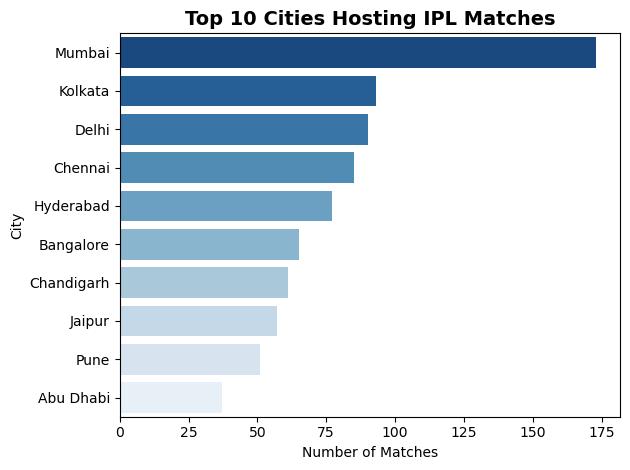

In [60]:
sns.barplot(
    x=top10_cities.values,
    y=top10_cities.index,
    palette='Blues_r'
)

plt.title("Top 10 Cities Hosting IPL Matches",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Number of Matches")
plt.ylabel("City")

plt.tight_layout()

plt.show()

# Interpretation

The visualization shows the Top 10 cities that have hosted IPL matches.

Mumbai has hosted the highest number of IPL matches, making it the primary host city in the tournament.
Kolkata and Delhi follow closely, reflecting their importance as long-standing IPL host cities.
Chennai, Hyderabad, and Bangalore have also hosted a substantial number of matches due to their established franchises and cricket infrastructure.
Cities such as Abu Dhabi appear in the list because they temporarily hosted IPL matches during seasons affected by external circumstances, such as the COVID-19 pandemic.

# Business Insight

The concentration of IPL matches in major metropolitan cities highlights the importance of well-developed cricket infrastructure, large stadium capacities, and strong fan bases. The inclusion of overseas venues such as Abu Dhabi demonstrates the IPL's flexibility in adapting to extraordinary situations while maintaining the continuity of the tournament.

In [61]:
cities = ['Mumbai', 'Delhi', None, 'Mumbai', 'Chennai']

In [62]:
pd.Series(cities).value_counts(dropna=False)

Mumbai     2
Delhi      1
None       1
Chennai    1
dtype: int64

# Business Question 7
Which batsmen have scored the most runs in IPL history?
# Objective

To identify the highest run-scoring batsmen in IPL history by analyzing the total runs scored by each player across all matches.

In [63]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [64]:
batsman_runs=deliveries.groupby('batter')['batsman_runs'].sum()
batsman_runs

batter
A Ashish Reddy     280
A Badoni           634
A Chandila           4
A Chopra            53
A Choudhary         25
                  ... 
Yashpal Singh       47
Younis Khan          3
Yudhvir Singh       22
Yuvraj Singh      2754
Z Khan             117
Name: batsman_runs, Length: 673, dtype: int64

In [65]:
batsman_runs=batsman_runs.sort_values(ascending=False)
batsman_runs

batter
V Kohli         8014
S Dhawan        6769
RG Sharma       6630
DA Warner       6567
SK Raina        5536
                ... 
S Ladda            0
S Lamichhane       0
Abdur Razzak       0
SS Cottrell        0
KM Asif            0
Name: batsman_runs, Length: 673, dtype: int64

In [66]:
tup10_batman_run=batsman_runs.head(10)
tup10_batman_run

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

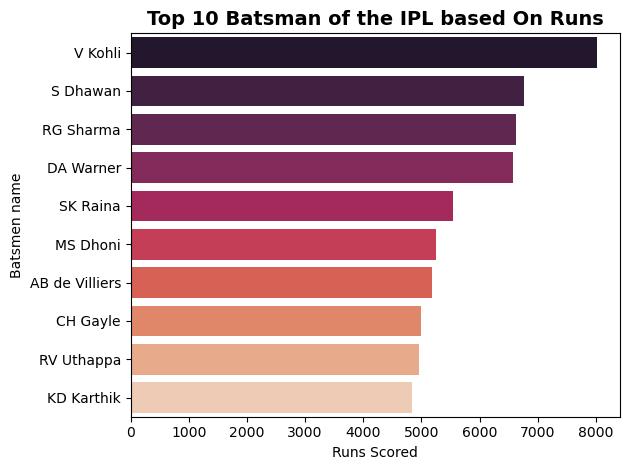

In [67]:
sns.barplot(y=tup10_batman_run.index,x=tup10_batman_run.values,palette='rocket')
plt.title("Top 10 Batsman of the IPL based On Runs",fontweight='bold',fontsize=14)
plt.ylabel("Batsmen name")
plt.xlabel("Runs Scored")
plt.tight_layout()
plt.show()

# Interpretation

The visualization presents the Top 10 highest run scorers in IPL history.

Virat Kohli leads the chart with over 8,000 runs, making him the highest run scorer in the tournament.
Shikhar Dhawan, Rohit Sharma, and David Warner also rank among the top run scorers, reflecting their consistency across multiple IPL seasons.
Experienced players such as Suresh Raina, MS Dhoni, and AB de Villiers continue to feature prominently, highlighting their long-term contributions to the league.
The gradual decline in total runs among the remaining players indicates a competitive group of elite batters who have consistently performed over the years.
# Business Insight

The highest run scorers have demonstrated exceptional consistency, longevity, and adaptability across different IPL seasons. These players form the core of successful batting line-ups and contribute significantly to their teams' overall performance. Such insights are valuable for franchise management when making decisions related to player retention, leadership roles, and auction strategies.

# Business Question 8
Which bowlers have taken the most wickets in IPL history?
# Objective

To identify the bowlers who have taken the highest number of wickets in IPL history and evaluate their contribution to their teams through consistent wicket-taking performances.

In [68]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [69]:
deliveries['dismissal_kind'].unique()

array([nan, 'caught', 'bowled', 'run out', 'lbw', 'retired hurt',
       'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field', 'retired out'], dtype=object)

In [70]:
deliveries['player_dismissed'].unique()

array([nan, 'SC Ganguly', 'RT Ponting', 'DJ Hussey', 'R Dravid',
       'V Kohli', 'JH Kallis', 'W Jaffer', 'MV Boucher', 'B Akhil',
       'CL White', 'AA Noffke', 'Z Khan', 'SB Joshi', 'PA Patel',
       'ML Hayden', 'MS Dhoni', 'SK Raina', 'JDP Oram', 'K Goel',
       'JR Hopes', 'Yuvraj Singh', 'KC Sangakkara', 'T Kohli',
       'YK Pathan', 'SR Watson', 'DS Lehmann', 'M Kaif', 'M Rawat',
       'RA Jadeja', 'SK Warne', 'V Sehwag', 'L Ronchi', 'DJ Thornely',
       'ST Jayasuriya', 'PR Shah', 'RV Uthappa', 'AM Nayar', 'SM Pollock',
       'S Chanderpaul', 'LRPL Taylor', 'Y Venugopal Rao', 'VVS Laxman',
       'AC Gilchrist', 'RG Sharma', 'SB Styris', 'AS Yadav', 'A Symonds',
       'WPUJC Vaas', 'SB Bangar', 'PP Ojha', 'BB McCullum', 'WP Saha',
       'Mohammad Hafeez', 'DPMD Jayawardene', 'IK Pathan', 'B Lee',
       'S Sohal', 'Kamran Akmal', 'Shahid Afridi', 'G Gambhir',
       'MEK Hussey', 'DJ Bravo', 'MA Khote', 'Harbhajan Singh',
       'GC Smith', 'D Salunkhe', 'RR Sarwan',

In [71]:
valid_wickets=deliveries[~deliveries['dismissal_kind'].isin([ 'run out',
    'retired hurt',
    'obstructing the field',
    'retired out'])]
valid_wickets.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [72]:
bowler_wickets=valid_wickets.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False)
bowler_wickets=bowler_wickets.head(10)

In [73]:
bowler_wickets

bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
Name: is_wicket, dtype: int64

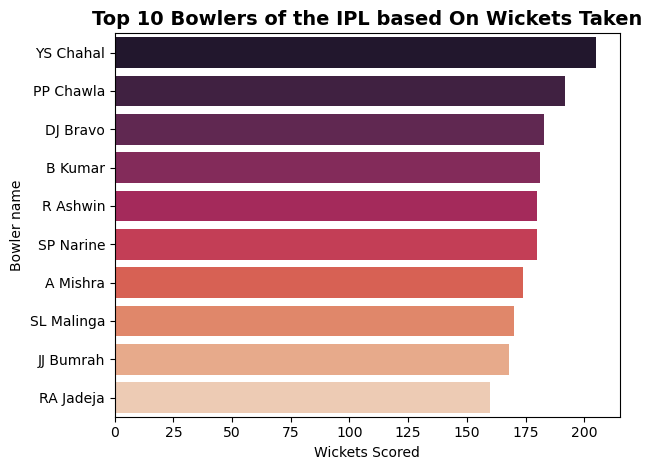

In [74]:
sns.barplot(y=bowler_wickets.index,x=bowler_wickets.values,palette='rocket')
plt.title("Top 10 Bowlers of the IPL based On Wickets Taken",fontweight='bold',fontsize=14)
plt.ylabel("Bowler name")
plt.xlabel("Wickets Scored")
plt.tight_layout()
plt.show()

# Interpretation

The visualization shows the Top 10 wicket-taking bowlers in IPL history.

Yuzvendra Chahal has taken the highest number of wickets, making him the leading wicket-taker in the dataset.
Piyush Chawla and Dwayne Bravo also rank among the top bowlers, demonstrating remarkable consistency across multiple IPL seasons.
Experienced bowlers such as Bhuvneshwar Kumar, Ravichandran Ashwin, Sunil Narine, and Lasith Malinga continue to feature among the leading wicket-takers, highlighting their sustained impact in T20 cricket.
The relatively small difference among the top bowlers indicates a highly competitive group of elite wicket-takers.

# Business Insight

Wicket-taking bowlers play a critical role in controlling the flow of runs and breaking key batting partnerships. Bowlers such as Yuzvendra Chahal, Dwayne Bravo, and Sunil Narine have consistently delivered match-winning performances over multiple IPL seasons, making them valuable assets for their franchises. Such analyses can support player retention decisions, auction strategies, and team composition.

In [75]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True


In [76]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


# Business Question 9
Which IPL teams have the highest average runs per innings?

# Objective

To identify which IPL teams consistently score the highest average runs per innings.

In [77]:
team_scores_per_inning=deliveries.groupby(["match_id","inning","batting_team"])['total_runs'].sum().reset_index()
team_scores_per_inning

,match_id,inning,batting_team,total_runs
0,335982,1,Kolkata Knight Riders,222
1,335982,2,Royal Challengers Bengaluru,82
2,335983,1,Chennai Super Kings,240
3,335983,2,Punjab Kings,207
4,335984,1,Rajasthan Royals,129
...,...,...,...,...
2212,1426310,2,Rajasthan Royals,174
2213,1426311,1,Sunrisers Hyderabad,175
2214,1426311,2,Rajasthan Royals,139
2215,1426312,1,Sunrisers Hyderabad,113


In [78]:
average_runs_per_innings=team_scores_per_inning.groupby('batting_team')['total_runs'].mean().sort_values(ascending=False)
average_runs_per_innings

batting_team
Gujarat Titans                 172.377778
Lucknow Super Giants           170.681818
Chennai Super Kings            162.306723
Mumbai Indians                 158.556391
Punjab Kings                   157.768924
Royal Challengers Bengaluru    157.449612
Gujarat Lions                  156.838710
Sunrisers Hyderabad            156.295699
Rajasthan Royals               155.816143
Kolkata Knight Riders          154.239216
Delhi Capitals                 153.109375
Deccan Chargers                152.840000
Rising Pune Supergiants        151.100000
Pune Warriors                  141.288889
Kochi Tuskers Kerala           135.785714
Name: total_runs, dtype: float64

In [79]:
top_10_avg_runs_team=average_runs_per_innings.head(10)
top_10_avg_runs_team

batting_team
Gujarat Titans                 172.377778
Lucknow Super Giants           170.681818
Chennai Super Kings            162.306723
Mumbai Indians                 158.556391
Punjab Kings                   157.768924
Royal Challengers Bengaluru    157.449612
Gujarat Lions                  156.838710
Sunrisers Hyderabad            156.295699
Rajasthan Royals               155.816143
Kolkata Knight Riders          154.239216
Name: total_runs, dtype: float64

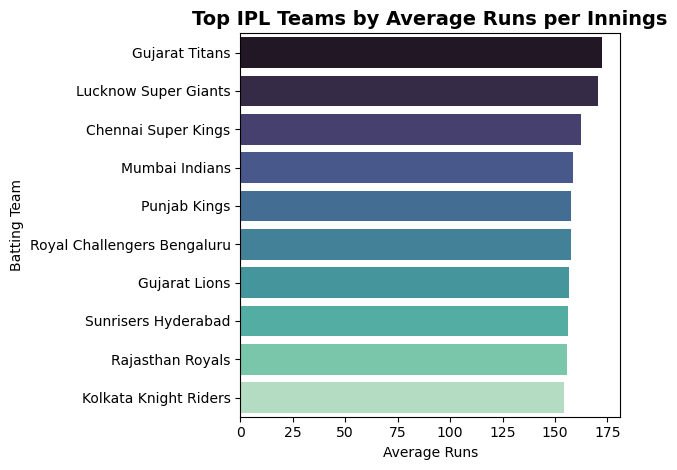

In [80]:
sns.barplot(x=top_10_avg_runs_team.values,y=top_10_avg_runs_team.index,palette='mako')
plt.title(
    "Top IPL Teams by Average Runs per Innings",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Average Runs")
plt.ylabel("Batting Team")

plt.tight_layout()

plt.show()

# Interpretation

The visualization ranks IPL teams based on their average runs scored per innings.

Gujarat Titans have the highest average innings score, indicating a strong and consistent batting unit despite being a relatively new franchise.
Lucknow Super Giants also rank near the top, reflecting impressive batting performances since joining the IPL.
Among the long-established franchises, Chennai Super Kings and Mumbai Indians continue to maintain high average scores, demonstrating sustained batting strength across multiple seasons.
The small differences among the top teams suggest that several franchises possess competitive batting line-ups capable of consistently posting strong totals.
# Business Insight

Teams with higher average innings scores generally possess strong top-order batters, effective middle-order partnerships, and the ability to maintain scoring momentum throughout an innings. These characteristics increase the likelihood of setting competitive targets or successfully chasing totals, making batting consistency a key factor in long-term success.

# Business Question 10
What are the highest team totals in IPL history?
# Objective

To identify the highest team scores recorded in a single innings and analyze which teams have posted the biggest totals in IPL history.

In [81]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [82]:
team_scores=deliveries.groupby(["match_id","inning","batting_team"])['total_runs'].sum().reset_index()
team_scores

,match_id,inning,batting_team,total_runs
0,335982,1,Kolkata Knight Riders,222
1,335982,2,Royal Challengers Bengaluru,82
2,335983,1,Chennai Super Kings,240
3,335983,2,Punjab Kings,207
4,335984,1,Rajasthan Royals,129
...,...,...,...,...
2212,1426310,2,Rajasthan Royals,174
2213,1426311,1,Sunrisers Hyderabad,175
2214,1426311,2,Rajasthan Royals,139
2215,1426312,1,Sunrisers Hyderabad,113


In [83]:
most_scored_team=team_scores.sort_values(by='total_runs',ascending=False)
most_scored_team

,match_id,inning,batting_team,total_runs
2133,1426268,1,Sunrisers Hyderabad,287
2089,1422126,1,Sunrisers Hyderabad,277
2105,1422134,1,Kolkata Knight Riders,272
2143,1426273,1,Sunrisers Hyderabad,266
709,598027,1,Royal Challengers Bengaluru,263
...,...,...,...,...
1533,1216493,4,Delhi Capitals,3
1573,1216512,4,Kolkata Knight Riders,3
1572,1216512,3,Sunrisers Hyderabad,2
1532,1216493,3,Punjab Kings,2


In [84]:
top10_team_totals = most_scored_team.head(10)

top10_team_totals

,match_id,inning,batting_team,total_runs
2133,1426268,1,Sunrisers Hyderabad,287
2089,1422126,1,Sunrisers Hyderabad,277
2105,1422134,1,Kolkata Knight Riders,272
2143,1426273,1,Sunrisers Hyderabad,266
709,598027,1,Royal Challengers Bengaluru,263
2158,1426280,2,Punjab Kings,262
2134,1426268,2,Royal Challengers Bengaluru,262
2157,1426280,1,Kolkata Knight Riders,261
2159,1426281,1,Delhi Capitals,257
2002,1359512,1,Lucknow Super Giants,257


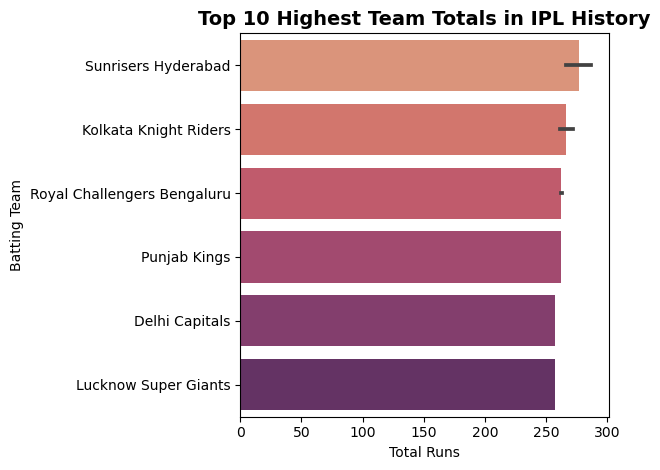

In [85]:
sns.barplot(x='total_runs',y='batting_team',data=top10_team_totals,palette='flare')
plt.title(
    "Top 10 Highest Team Totals in IPL History",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Total Runs")
plt.ylabel("Batting Team")

plt.tight_layout()

plt.show()# seaborn  behaviour

In [86]:
top10_team_totals = top10_team_totals.copy()

top10_team_totals['team_innings'] = (
    top10_team_totals['batting_team']
    + ' (Match '
    + top10_team_totals['match_id'].astype(str)
    + ')'
)

In [87]:
top10_team_totals

,match_id,inning,batting_team,total_runs,team_innings
2133,1426268,1,Sunrisers Hyderabad,287,Sunrisers Hyderabad (Match 1426268)
2089,1422126,1,Sunrisers Hyderabad,277,Sunrisers Hyderabad (Match 1422126)
2105,1422134,1,Kolkata Knight Riders,272,Kolkata Knight Riders (Match 1422134)
2143,1426273,1,Sunrisers Hyderabad,266,Sunrisers Hyderabad (Match 1426273)
709,598027,1,Royal Challengers Bengaluru,263,Royal Challengers Bengaluru (Match 598027)
2158,1426280,2,Punjab Kings,262,Punjab Kings (Match 1426280)
2134,1426268,2,Royal Challengers Bengaluru,262,Royal Challengers Bengaluru (Match 1426268)
2157,1426280,1,Kolkata Knight Riders,261,Kolkata Knight Riders (Match 1426280)
2159,1426281,1,Delhi Capitals,257,Delhi Capitals (Match 1426281)
2002,1359512,1,Lucknow Super Giants,257,Lucknow Super Giants (Match 1359512)


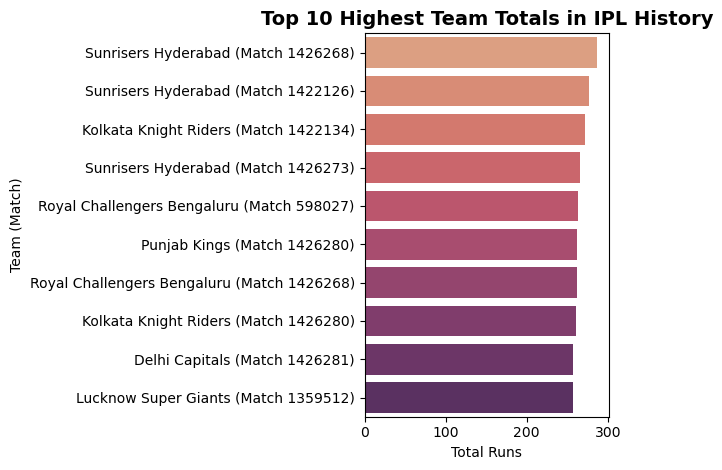

In [88]:
sns.barplot(
    data=top10_team_totals,
    x='total_runs',
    y='team_innings',
    palette='flare'
)

plt.title("Top 10 Highest Team Totals in IPL History", fontsize=14, fontweight='bold')
plt.xlabel("Total Runs")
plt.ylabel("Team (Match)")
plt.tight_layout()
plt.show()

# Business Question 11
How are IPL matches usually won? (By Runs or By Wickets?)

In [89]:
matches.head(10)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,False
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,...,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,False
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,False
5,335987,2007/08,Jaipur,2008-04-21,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Punjab Kings,Punjab Kings,...,Rajasthan Royals,wickets,6.0,167.0,20.0,N,NaN,Aleem Dar,RB Tiffin,False
6,335988,2007/08,Hyderabad,2008-04-22,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Delhi Capitals,Deccan Chargers,...,Delhi Capitals,wickets,9.0,143.0,20.0,N,NaN,IL Howell,AM Saheba,False
7,335989,2007/08,Chennai,2008-04-23,League,ML Hayden,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Mumbai Indians,Mumbai Indians,...,Chennai Super Kings,runs,6.0,209.0,20.0,N,NaN,DJ Harper,GA Pratapkumar,False
8,335990,2007/08,Hyderabad,2008-04-24,League,YK Pathan,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,Rajasthan Royals,...,Rajasthan Royals,wickets,3.0,215.0,20.0,N,NaN,Asad Rauf,MR Benson,True
9,335991,2007/08,Chandigarh,2008-04-25,League,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Mumbai Indians,Mumbai Indians,...,Punjab Kings,runs,66.0,183.0,20.0,N,NaN,Aleem Dar,AM Saheba,False


In [90]:
result_type=matches['result'].value_counts()
result_type

wickets      578
runs         498
tie           14
no result      5
Name: result, dtype: int64

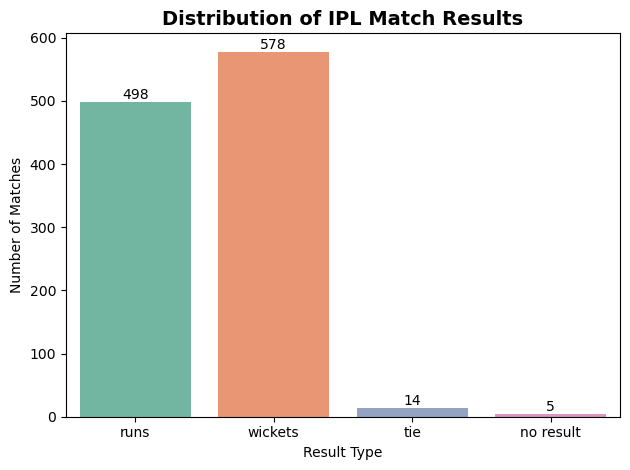

In [91]:
ax = sns.countplot(data=matches, x='result', palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of IPL Match Results",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Result Type")
plt.ylabel("Number of Matches")

plt.tight_layout()

plt.show()

# Interpretation

The visualization illustrates the distribution of IPL match outcomes based on the result type.

Winning by wickets is the most common outcome, accounting for approximately 578 matches.
Winning by runs follows closely with around 499 matches.
Tied matches are extremely rare, indicating that IPL matches usually produce a clear winner.
No-result matches occur very infrequently and are generally caused by external factors such as weather interruptions.

Overall, the analysis suggests that successful run chases have been slightly more common than successful score defenses in IPL history.

# Business Insight

The higher number of victories by wickets suggests that teams have often been successful while chasing targets. This highlights the importance of strong batting depth, effective planning during run chases, and adaptability under pressure. The rarity of ties and no-result matches reflects the competitive nature of the IPL and the tournament's ability to produce decisive outcomes.

# Business Question 12
Which IPL seasons had the highest number of matches?
# Objective

To analyze the growth of the IPL by identifying the number of matches played in each season and understanding how the tournament has expanded over time.

In [92]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True


In [93]:
season_matches=matches['season'].value_counts().sort_index()
season_matches

2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: season, dtype: int64

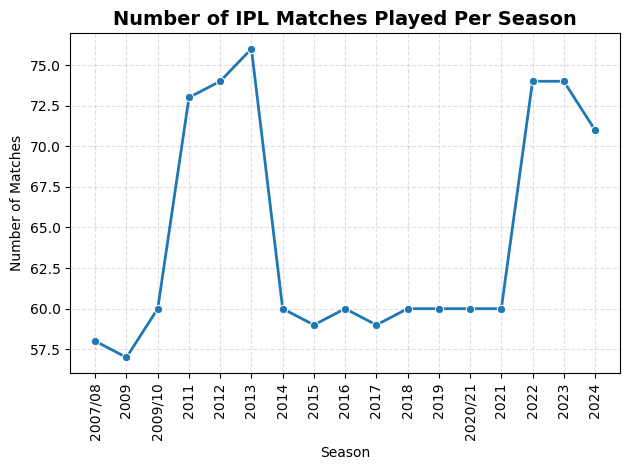

In [94]:
sns.lineplot(x=season_matches.index,y=season_matches.values,marker='o',linewidth=2)
plt.title(
    "Number of IPL Matches Played Per Season",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.xticks(rotation=90)
# plt.grid(alpha=0.3)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

# Interpretation

The line chart illustrates the number of IPL matches played in each season.

The tournament started with 58 matches in the inaugural 2008 season.
The number of matches gradually increased, reaching 76 matches in 2013, reflecting the expansion of the tournament.
Between 2014 and 2021, the IPL maintained a relatively stable schedule of around 59–60 matches per season.
From 2022 onwards, the number of matches increased again to approximately 74 matches, coinciding with the introduction of Gujarat Titans and Lucknow Super Giants.
In 2024, the number of matches slightly decreased to 71, while still remaining significantly higher than earlier seasons.
# Business Insight

The increasing number of IPL matches over time reflects the league's continuous growth and commercial success. Expansion through the addition of new franchises and changes in tournament structure have created more playing opportunities, increased fan engagement, and enhanced broadcasting and sponsorship revenues. The IPL has evolved from a relatively small tournament into one of the world's largest professional T20 cricket leagues.

# Business Question 13 
Does scoring above 180 runs increase a team's chances of winning?
# Business Objective

In T20 cricket, 180 runs is often considered a competitive score. Teams frequently aim to cross this mark when batting first.

The objective of this analysis is to determine whether scoring more than 180 runs significantly increases the probability of winning an IPL match.

In [95]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [96]:
team_scores=deliveries.groupby(["match_id","inning","batting_team"])['total_runs'].sum().reset_index()
team_scores.head()

,match_id,inning,batting_team,total_runs
0,335982,1,Kolkata Knight Riders,222
1,335982,2,Royal Challengers Bengaluru,82
2,335983,1,Chennai Super Kings,240
3,335983,2,Punjab Kings,207
4,335984,1,Rajasthan Royals,129


In [97]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True


In [98]:
merged_data=pd.merge(team_scores,matches[['id','winner']],left_on='match_id',right_on='id',how='left')
merged_data.head()

,match_id,inning,batting_team,total_runs,id,winner
0,335982,1,Kolkata Knight Riders,222,335982,Kolkata Knight Riders
1,335982,2,Royal Challengers Bengaluru,82,335982,Kolkata Knight Riders
2,335983,1,Chennai Super Kings,240,335983,Chennai Super Kings
3,335983,2,Punjab Kings,207,335983,Chennai Super Kings
4,335984,1,Rajasthan Royals,129,335984,Delhi Capitals


In [99]:
merged_data['runs_over_180']=(merged_data['total_runs']>180)

In [100]:
merged_data['runs_over_180']

0        True
1       False
2        True
3        True
4       False
        ...  
2212    False
2213    False
2214    False
2215    False
2216    False
Name: runs_over_180, Length: 2217, dtype: bool

In [101]:
merged_data['won_match']=(merged_data['batting_team']==merged_data['winner'])

In [102]:
merged_data['won_match']

0        True
1       False
2        True
3       False
4       False
        ...  
2212     True
2213     True
2214    False
2215    False
2216     True
Name: won_match, Length: 2217, dtype: bool

In [103]:
winning_percentage=merged_data.groupby('runs_over_180')['won_match'].mean()*100

In [104]:
winning_percentage

runs_over_180
False    44.800951
True     65.730337
Name: won_match, dtype: float64

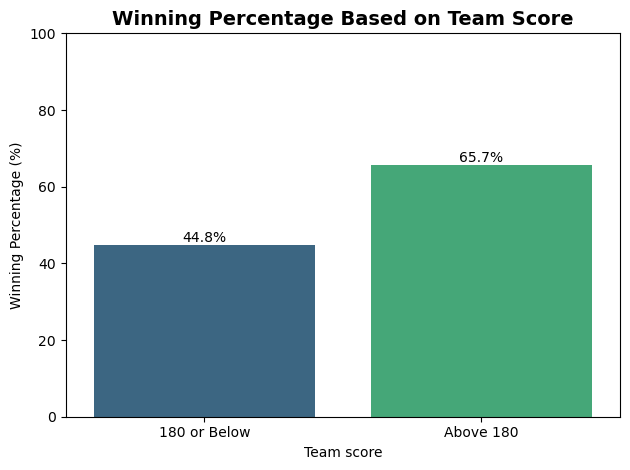

In [105]:

ax = sns.barplot(
    x=['180 or Below', 'Above 180'],
    y=winning_percentage.values,
    palette='viridis'
)

plt.title(
    "Winning Percentage Based on Team Score",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Team score")
plt.ylabel("Winning Percentage (%)")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylim(0,100)

plt.tight_layout()

plt.show()

# Interpretation

The chart compares the winning percentage of teams based on whether they scored more than 180 runs in an innings.

Teams scoring 180 runs or fewer won approximately 45% of their innings.
Teams scoring more than 180 runs won approximately 66% of their innings.
This represents a substantial increase in the probability of winning when crossing the 180-run mark.
However, since the winning percentage is not 100%, the analysis indicates that scoring above 180 does not guarantee victory, as bowling performance, fielding, match conditions, and the opposition's batting strength also influence the outcome.
# Business Insight

Scoring more than 180 runs significantly improves a team's chances of winning an IPL match, increasing the winning percentage from approximately 45% to 66%. This suggests that 180 runs is an effective benchmark for a competitive T20 score. However, teams should not rely solely on batting, as strong bowling and fielding remain essential to convert high scores into victories.

# Business Question 14
Which teams score the highest average runs in matches they win?

# Business Objective

The objective is to identify which IPL teams score the highest average runs in matches they win. This helps evaluate the batting performance required for successful outcomes rather than simply analyzing scores across all matches.

In [106]:
winning_innings=merged_data[merged_data['batting_team'] == merged_data['winner']]
winning_innings.head()

,match_id,inning,batting_team,total_runs,id,winner,runs_over_180,won_match
0,335982,1,Kolkata Knight Riders,222,335982,Kolkata Knight Riders,True,True
2,335983,1,Chennai Super Kings,240,335983,Chennai Super Kings,True,True
5,335984,2,Delhi Capitals,132,335984,Delhi Capitals,False,True
7,335985,2,Royal Challengers Bengaluru,166,335985,Royal Challengers Bengaluru,False,True
9,335986,2,Kolkata Knight Riders,112,335986,Kolkata Knight Riders,False,True


In [107]:
average_winning_score = (
    winning_innings
    .groupby('batting_team')['total_runs']
    .mean()
    .sort_values(ascending=False)
)
average_winning_score

batting_team
Lucknow Super Giants           183.875000
Gujarat Titans                 175.571429
Chennai Super Kings            169.108696
Gujarat Lions                  167.076923
Mumbai Indians                 165.664384
Rajasthan Royals               165.614035
Royal Challengers Bengaluru    165.152000
Sunrisers Hyderabad            163.123596
Punjab Kings                   162.370690
Delhi Capitals                 162.127119
Kolkata Knight Riders          158.924242
Deccan Chargers                158.551724
Pune Warriors                  151.083333
Rising Pune Supergiants        146.133333
Kochi Tuskers Kerala           141.000000
Name: total_runs, dtype: float64

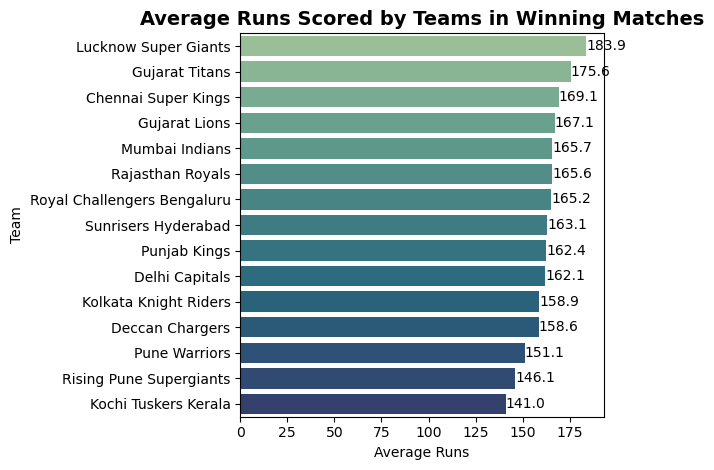

In [108]:
ax = sns.barplot(
    x=average_winning_score.values,
    y=average_winning_score.index,
    palette='crest'
)

plt.title(
    "Average Runs Scored by Teams in Winning Matches",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Average Runs")
plt.ylabel("Team")

# Optional: Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()

plt.show()

# Interpretation

The visualization ranks IPL teams based on their average runs scored in matches they won.

Lucknow Super Giants have the highest average winning score at approximately 183.9 runs, indicating that they generally post high totals when they secure victories.
Gujarat Titans follow with an average of approximately 175.6 runs, reflecting their strong batting performances in winning matches.
Established franchises such as Chennai Super Kings, Mumbai Indians, and Royal Challengers Bengaluru also maintain high average winning scores, demonstrating consistent batting strength.
Teams such as Kochi Tuskers Kerala, Rising Pune Supergiants, and Pune Warriors have comparatively lower average winning scores, although these values should be interpreted cautiously because these franchises participated in fewer IPL seasons.

# Business Insight

Teams like Lucknow Super Giants and Gujarat Titans typically score higher totals in the matches they win, indicating an aggressive batting strategy. However, several successful franchises achieve victories with comparatively lower average scores, suggesting that effective bowling, fielding, and match management are equally important in determining match outcomes.

# Business Question 15
What are the highest batting performances by Player of the Match winners in IPL history?

# Business Objective

The objective is to determine whether Player of the Match (POTM) awards are primarily awarded for outstanding batting performances by comparing the runs scored by the award winner in that match.

In [109]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [110]:
batter_match_runs =deliveries.groupby(["match_id","batter"])["batsman_runs"].sum().reset_index()
batter_match_runs.head()

,match_id,batter,batsman_runs
0,335982,AA Noffke,9
1,335982,B Akhil,0
2,335982,BB McCullum,158
3,335982,CL White,6
4,335982,DJ Hussey,12


In [111]:
potm_runs = pd.merge(
    matches[['id', 'player_of_match']],
    batter_match_runs,
    left_on=['id', 'player_of_match'],
    right_on=['match_id', 'batter'],
    how='left'
)

potm_runs.head()

,id,player_of_match,match_id,batter,batsman_runs
0,335982,BB McCullum,335982.0,BB McCullum,158.0
1,335983,MEK Hussey,335983.0,MEK Hussey,116.0
2,335984,MF Maharoof,NaN,NaN,NaN
3,335985,MV Boucher,335985.0,MV Boucher,39.0
4,335986,DJ Hussey,335986.0,DJ Hussey,38.0


In [112]:
top10_potm_runs = (
    potm_runs
    .sort_values(by='batsman_runs', ascending=False)
    .head(10)
)

top10_potm_runs

,id,player_of_match,match_id,batter,batsman_runs
352,598027,CH Gayle,598027.0,CH Gayle,175.0
0,335982,BB McCullum,335982.0,BB McCullum,158.0
941,1304112,Q de Kock,1304112.0,Q de Kock,140.0
502,829795,AB de Villiers,829795.0,AB de Villiers,133.0
761,1216510,KL Rahul,1216510.0,KL Rahul,132.0
560,980987,AB de Villiers,980987.0,AB de Villiers,129.0
1022,1370352,Shubman Gill,1370352.0,Shubman Gill,129.0
312,548372,CH Gayle,548372.0,CH Gayle,128.0
146,419137,M Vijay,419137.0,M Vijay,127.0
612,1082627,DA Warner,1082627.0,DA Warner,126.0


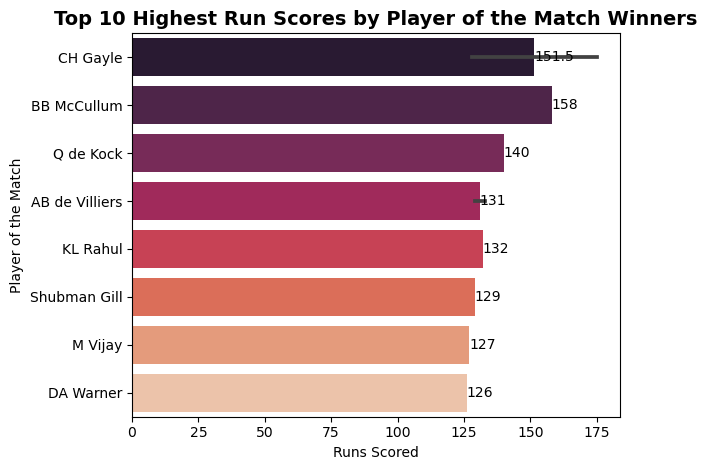

In [113]:
ax = sns.barplot(
    data=top10_potm_runs,
    x='batsman_runs',
    y='player_of_match',
    palette='rocket'
)

plt.title(
    "Top 10 Highest Run Scores by Player of the Match Winners",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Runs Scored")
plt.ylabel("Player of the Match")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [115]:
matches.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True


In [116]:
top10_potm_runs = top10_potm_runs.copy()

top10_potm_runs['player_match'] = (
    top10_potm_runs['player_of_match']
    + " (Match "
    + top10_potm_runs['id'].astype(str)
    + ")"
)

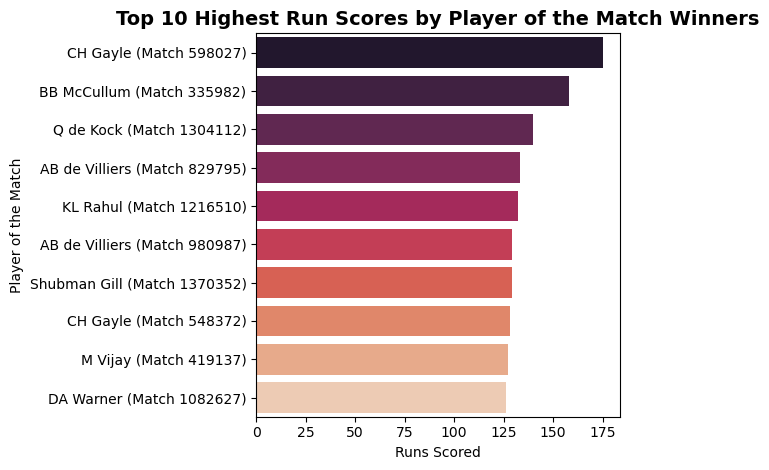

In [117]:
sns.barplot(
    data=top10_potm_runs,
    x='batsman_runs',
    y='player_match',
    palette='rocket'
)
plt.title(
    "Top 10 Highest Run Scores by Player of the Match Winners",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Runs Scored")
plt.ylabel("Player of the Match")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Interpretations :
    
The visualization presents the highest individual batting performances by players who received the Player of the Match award in IPL history.

Chris Gayle holds the highest score with 175 runs, one of the greatest innings in IPL history.
Brendon McCullum follows with 158 runs, setting the tone for the inaugural IPL season.
AB de Villiers and Chris Gayle each appear multiple times, demonstrating their ability to deliver exceptional match-winning innings on more than one occasion.
The majority of the top performances exceed 125 runs, highlighting the strong influence of dominant batting displays in earning the Player of the Match award.

# Business Insight

Exceptional batting performances frequently play a decisive role in earning the Player of the Match award. Several players, including Chris Gayle and AB de Villiers, appear multiple times among the highest-scoring award-winning innings, demonstrating their ability to consistently produce match-defining performances. However, Player of the Match awards are not exclusively determined by batting, as bowlers and all-rounders are also recognized for outstanding contributions.

# Overall Findings

- Mumbai Indians have won the highest number of matches in IPL history, highlighting their long-term consistency.
- Gujarat Titans recorded the highest win percentage among all franchises, reflecting an impressive start since joining the IPL.
- Winning the toss has only a marginal impact on match outcomes, with teams winning after the toss approximately half of the time.
- Virat Kohli is the highest run scorer in IPL history, while Yuzvendra Chahal has taken the most wickets.
- Chris Gayle has produced the highest batting performance among Player of the Match winners with his iconic 175-run innings.
- Eden Gardens and Wankhede Stadium have hosted the highest number of IPL matches, making them two of the most prominent IPL venues.
- Mumbai has hosted more IPL matches than any other city, emphasizing its significance in the tournament.
- Teams scoring more than 180 runs achieve a considerably higher winning percentage than teams scoring 180 runs or fewer.
- Lucknow Super Giants and Gujarat Titans record the highest average runs in matches they win, indicating strong batting performances during victories.
- The number of IPL matches has steadily increased over the years, reflecting the expansion and growing popularity of the tournament.

# Conclusion

This project explored IPL match and ball-by-ball datasets using Python, Pandas, Matplotlib, and Seaborn to uncover meaningful insights into team performance, player achievements, batting trends, bowling effectiveness, venue statistics, and tournament growth.

The analysis demonstrated that successful IPL teams rely on a combination of consistent batting, effective bowling, and strategic decision-making rather than any single performance metric. Advanced analyses using merged datasets further revealed that scoring above 180 runs significantly increases the probability of winning, while outstanding batting performances frequently contribute to earning the Player of the Match award.

Overall, this project demonstrates practical data analysis techniques including data cleaning, exploratory data analysis (EDA), feature engineering, data merging, aggregation, and visualization to answer real-world business questions.

# Future Scope

This analysis can be further extended by:

- Developing predictive machine learning models to forecast match winners.
- Analyzing player strike rates and bowling economy rates.
- Building partnership analysis between batting pairs.
- Evaluating team performance at different venues and against specific opponents.
- Creating interactive dashboards using Power BI, Tableau, or Streamlit.
- Performing season-wise player performance analysis.
- Applying advanced statistical techniques and predictive analytics for cricket strategy.

# Skills Demonstrated

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Feature Engineering
- Data Merging
- GroupBy Operations
- Business Insight Generation

# Pandas Concepts Used

- read_csv()
- head()
- tail()
- shape
- columns
- info()
- describe()
- isnull()
- duplicated()
- value_counts()
- unique()
- nunique()
- replace()
- to_datetime()
- groupby()
- agg()
- sort_values()
- sort_index()
- reset_index()
- merge()
- isin()
- Boolean Indexing
- Feature Engineering

# Visualizations Used

- Count Plot
- Bar Plot
- Horizontal Bar Plot
- Pie Chart
- Line Plot

# Business Questions Answered

1. Which IPL team has won the most matches?
2. Which team has the highest win percentage?
3. Does winning the toss influence match outcomes?
4. Which players have won the most Player of the Match awards?
5. Which IPL venues have hosted the most matches?
6. Which cities have hosted the most IPL matches?
7. Which batsmen have scored the most runs?
8. Which bowlers have taken the most wickets?
9. Which teams have the highest average runs per innings?
10. What are the highest team totals in IPL history?
11. How are IPL matches usually won?
12. Which IPL seasons had the highest number of matches?
13. Does scoring above 180 runs increase a team's chances of winning?
14. Which teams score the highest average runs in matches they win?
15. What are the highest batting performances by Player of the Match winners in IPL history?

# Limitations

- Some franchises participated in fewer IPL seasons, which may influence average-based comparisons.
- Player and team performances are analyzed using historical data only and do not account for future performance.
- The analysis focuses on descriptive insights and does not include predictive modeling.
- External factors such as weather, pitch conditions, injuries, and player availability were not considered.

# Project Summary

This project analyzed over 1,000 IPL matches and more than 260,000 ball-by-ball records to uncover insights into team performance, player achievements, scoring trends, bowling effectiveness, venues, tournament growth, and match-winning factors.

Using Python and the Pandas library, multiple business questions were answered through data cleaning, aggregation, feature engineering, data merging, and visualization. The project demonstrates practical data analysis skills commonly applied in real-world sports analytics and business intelligence.